# Tutorial 2: Trajectory Inference using Palantir

## Introduction 

ATLAS is a multi-omics framework that supports trajectory inference on multi-omics data. ATLAS is build upon estimated TI tools for trajectory inference such as Palantir {cite}`palantir` and CellRank {cite}`cellrank2`. 

In this set of tutorials, you will learn how to: 
- Construct a multimodal container conatining gene expression and gene activity data
- Perform trajectory inference using Palantir as underlying TI strategy
- Perform trajecotry inference unsing CellRank as underlying TI strategy
- Evaluate results from the trajectory inference 
- Perform multimodal plots 

Data for this tutorial are available here or can be downloaded according to the following bash command:

In [1]:
!mkdir -p data && cd data

In this tutorial we analyze a multimodal SHARE-seq dataset of mouse hair follicle cells {cite}`shareseq`. 

The dataset includes `hair follicle stem cells` (HFSCs), `transit-amplifying cells` (TACs), and their differentiated progeny along multiple lineages, such as the `hair-shaft medulla`, the  `hair-shaft cuticle cortex` and the `inner root sheat`  (IRS), making it an ideal benchmark for multimodal trajectory inference.

The {class}`muon.MuData` object is already preprocessed and contains two modalities: `rna` with gene expression values and `activity` with gene activity values. Preprocessing followed similar computations as illustrated in Tutorial 1 and is available *at this link*. 

In [2]:
import os
import atlas
import scanpy as sc
import muon as mu
import numpy as np

seed = 42
rng = np.random.default_rng(seed)
np.random.seed(seed)


data_path = os.path.join(os.getcwd(), "data")
initial_data = mu.read_h5mu(os.path.join(data_path, "hair.h5mu"))
initial_data

/Users/lrcq/atlasVenv/lib/python3.12/site-packages/mudata/_core/mudata.py:931: UserWarning: Cannot join columns with the same name because var_names are intersecting.
  warnings.warn(


MuData object with n_obs × n_vars = 6649 × 43421
  obs:	'atac.bc', 'celltype'
  2 modalities
    rna:	6649 x 21717
      obs:	'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier'
      var:	'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
      uns:	'hvg', 'log1p', 'pca'
      obsm:	'X_pca'
      varm:	'PCs'
    activity:	6649 x 21704
      obs:	'frag_barcode_raw', 'n_genes_by_counts', 'total_counts', 'nucleosome_signal', 'nuc_filter', 'outlier'
      var:	'OR_Chromosome', 'Chromosome', 'Strand', 'Start', 'End'
      uns:	'pca'
      obsm:	'X_pca'
      varm:	'PCs'

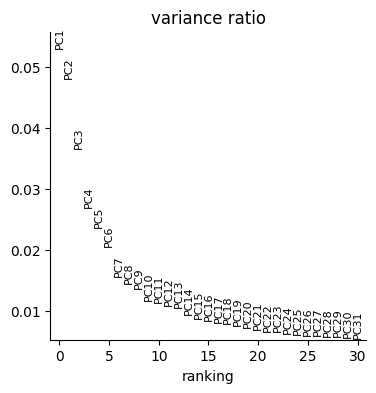

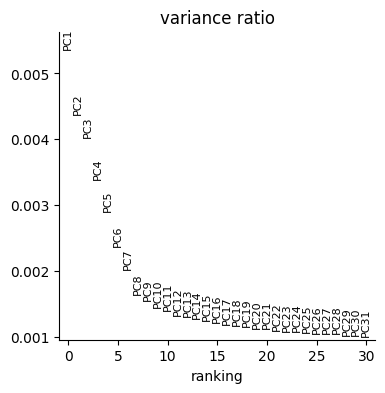

In [3]:
p1 = sc.pl.pca_variance_ratio(initial_data["rna"])
p2 = sc.pl.pca_variance_ratio(initial_data["activity"])

We now need to obtain the Weighted Nearest Neighbor (WNN) graph {cite}`wnn` as explained in Tutorial 1. We exploit ATLAS preprocessing function to create the WNN and UMAP. 

We already provided the `activity` modality, therefore we don't need to feed the preprocessing function with genomics coordinates or the fragments file path and we set these two options to `None`. The {func}`atlas.pp.preprocessing` computes single-modalities K-Nearest Neighbors (KNN) graphs, the WNN and the UMAP 2D visualization. 

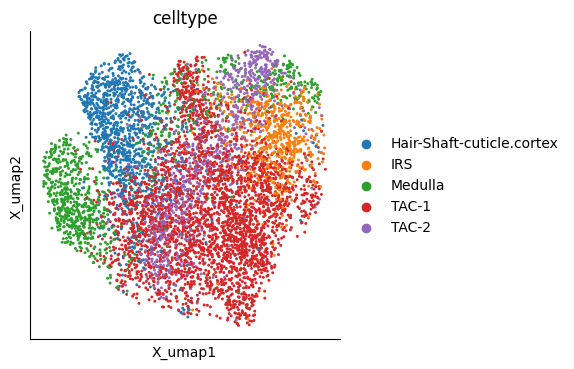

In [4]:
knn_rna, knn_act, wnn = 15, 15, None
n_pcs_rna, n_pcs_act = 20, 10

mudata = atlas.pp.preprocessing(
    mudata=initial_data,
    n_pcs_rna=n_pcs_rna,
    n_pcs_act=n_pcs_act,
    knn_rna=knn_rna,
    knn_act=knn_act,
    n_neighbors=wnn,
    features=None,
    fragment_path=None,
    random_state=seed,
)

mu.pl.embedding(mudata, basis="X_umap", color=["celltype"])

## Trajectory Inference using ATLAS

This tutorial focuses on:
- Performing TI with ATLAS using `Palantir` as the underlying strategy.

Palantir {cite}`palantir` is a framework that originally applies diffusion maps to the gene expression manifold. Its underlying assumption is that, during development, cell state changes are incremental: one expects to observe small, gradual transitions rather than abrupt jumps. Under this assumption, a KNN graph built on single-cell data is able to reconstruct a manifold that connects cells with similar expression states, thereby capturing cell state evolution.

ATLAS extends Palantir's capabilities to multi-omics data, based on the consideration that development is driven not only by gene expression, but also by the underlying regulatory mechanisms. Consequently, ATLAS TI (Palantir-based) generalizes the original assumption of incremental cell state changes to a manifold that incorporates complementary information about gene regulation.

From the perspective of this tutorial, ATLAS extends Palantir's functionalities to MuData objects through the {class}`~atlas.tl.PalantirExtension` class. The extended functionalities include:
- Computation of the anisotropic gaussian kernel
- Computation of diffusion maps
- Computation of the multiscale space
- Inference of pseudotime, developmental branches, and cell-fate probabilities

Mathematical details about Palantir are described in the original publication {cite}`palantir`.

In [5]:
# Palantir requires ad initial cell to be specified, we here identify a random cell from the "TAC-1"
initial = rng.choice(mudata[mudata.obs["celltype"] == "TAC-1"].obs_names)

pex = atlas.tl.PalantirExtension(mudata=mudata)
pex.compute_kernel()
pex.compute_diffusion_maps(seed=seed)
pex.compute_multiscale_space()

pex.run(
    early_cell=initial,
    cluster_key="celltype",
    pseudotime_key="pseudotime",
    fate_prob_key="palantir_probabilities",
    terminal_states=None,
    n_jobs=-1,
    random_state=seed,
)

mudata

Sampling and flocking waypoints...
Time for determining waypoints: 0.004365583260854085 minutes
Determining pseudotime...
Shortest path distances using 30-nearest neighbor graph...
Time for shortest paths: 0.15162305037180582 minutes
Iteratively refining the pseudotime...
Correlation at iteration 1: 0.9980
Correlation at iteration 2: 0.9999
Entropy and branch probabilities...
Markov chain construction...
Identification of terminal states...
Computing fundamental matrix and absorption probabilities...
Project results to all cells...


MuData object with n_obs × n_vars = 6649 × 43421
  obs:	'atac.bc', 'celltype', 'pseudotime', 'shannon_entropy', 'kl_divergence'
  uns:	'wnn', 'umap', 'celltype_colors', 'DM_EigenValues', 'palantir_waypoints', 'initial_states', 'terminal_states', 'fate_state_colors'
  obsm:	'X_umap', 'DM_EigenVectors', 'DM_EigenVectors_multiscaled', 'palantir_probabilities'
  obsp:	'wnn_distances', 'wnn_connectivities', 'DM_Kernel', 'DM_Similarity'
  2 modalities
    rna:	6649 x 21717
      obs:	'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier'
      var:	'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
      uns:	'hvg', 'log1p', 'pca', 'neighbors'
      obsm:	'X_pca'
      varm:	'PCs'
      obsp:	'distances', 'connectivities'
    activity:	6649 x 21704
      obs:	'frag_barcode_raw', 'n_genes_by_counts', 'total_counts', 'nucleosome_signal', 'nuc_filter', 'outlier'
      var:	'OR_Chromosome', 'Chromosome', 'Strand', 'Start', 'End'
      uns:	'pca', 'neighbors'
      obsm:	'X_pca'
      varm:	'PCs'
      obsp:	'distances', 'connectivities'

{class}`~atlas.tl.PalantirExtension` accepts as input the multiomics instance and applies palantir-like functions. The {meth}`~atlas.tl.PalantirExtension.run` method computed pseudotime and cell-wise fate probabilites. By Default, 10 diffusion components are computed.

The multimodal object now stores additional results: 
- A `pseudotime` columns is added to the `.obs` slot and contains cell ordering. This value ranges in the $[0,1]$ interval.
- Two columns containing entropy measures are added to the `.obs` slot, namely `shannon_entropy` and `kl_divergence`. These are mesurements for cell plasticity. 
- `initial_states` and `terminal_states` are added to the `.uns` slot. These dictionaries contain the list of identifies terminal and initial states. 
- `fate_state_colors` is added to the `.uns` slot. 
- `palantir_probabilities` is added to the `.obsm` slot. These are the cell fate probabilities towards the inferred branches. 
- `DM_Eigenvalues` added to the `.uns` slot, which are the eigenvalues associated to the diffusion components.
- `DM_Eigenvectors` added to the `.obsm` slot, the diffusion components
- `DM_Eigenvectors_multiscaled` added to the `.obsm` slot, the multiscale space representation computed in Palantir.
- `DM_Kernel` and `DM_Similarity` added to the `.obsp` slot, where results from the anisotropic gaussian kernel are stored.

We will here use ATLAS plotting functions to visualize results form the TI process, such as the pseudotime, the entropy measures and the fate probability distribution over the UMAP embedding.

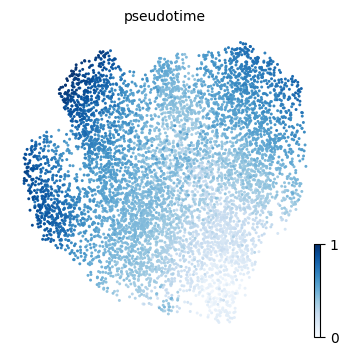

In [6]:
p1 = atlas.pl.plot_embedding(mudata, observation="pseudotime")

In [7]:
mudata.obs["pseudotime"].to_csv(os.path.join(data_path, "pseudotime.csv"), header=False, index=True)